# F1 — Prédiction de Pit Stop

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder


In [27]:
df = pd.read_csv('f1_strategy_dataset_v4.csv').dropna(subset=['Compound'])

# LabelEncoder : les algos ML ne lisent que des nombres
# HARD->0, INTERMEDIATE->1, MEDIUM->2, SOFT->3, WET->4
le = LabelEncoder()
df['Compound_enc'] = le.fit_transform(df['Compound'])
print('Mapping composes :', dict(zip(le.classes_, le.transform(le.classes_))))

# Features (X) : les informations connues AVANT le pit stop
# Ce sont les entrees du modele — ce qu'il a le droit de voir pour predire
FEATURES = [
    'TyreLife',              # nombre de tours sur ce jeu de pneus
    'Compound_enc',          # type de pneu encode en entier
    'Cumulative_Degradation',# usure accumulee en secondes perdues
    'LapTime_Delta',         # ecart de temps vs tour precedent
    'Position',              # position en course
    'RaceProgress',          # avancement de la course (0.0 -> 1.0)
    'Normalized_TyreLife',   # TyreLife ramene entre 0 et 1
    'Stint',                 # numero du relais en cours
]
# Cible (y) : ce qu'on veut predire — 1 = pit stop au prochain tour, 0 = pas de pit
TARGET = 'PitNextLap'

X = df[FEATURES]
y = df[TARGET]

print(f'X : {X.shape} | y : {y.shape}')
# Le ratio ~25% montre un desequilibre de classes : 3x plus de 'pas de pit' que de pit
print(f'Ratio pit stops : {y.mean():.2%}')

Mapping composes : {'HARD': 0, 'INTERMEDIATE': 1, 'MEDIUM': 2, 'SOFT': 3, 'WET': 4}
X : (101305, 8) | y : (101305,)
Ratio pit stops : 25.46%


In [28]:
# Separation train / test
# test_size=0.2 -> 80% pour apprendre, 20% pour evaluer sur des donnees jamais vues
# random_state=42 -> graine fixe : resultats reproductibles a chaque execution
# stratify=y -> preserve le ratio pit/pas-de-pit dans chaque partie (evite le biais)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50, stratify=y
)
print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')

Train : 81,044 | Test : 20,261


In [29]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=50, n_jobs=-1)

# Apprentissage sur les donnees d'entrainement
rf.fit(X_train, y_train)

# Predictions sur le jeu de test
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Pas de pit', 'Pit']))

=== Random Forest ===
              precision    recall  f1-score   support

  Pas de pit       0.93      0.97      0.95     15103
         Pit       0.89      0.78      0.83      5158

    accuracy                           0.92     20261
   macro avg       0.91      0.88      0.89     20261
weighted avg       0.92      0.92      0.92     20261



In [30]:
# Regression Logistique
# Principe : calcule une combinaison lineaire des features, puis applique la fonction
# sigmoide pour obtenir une probabilite entre 0 et 1.
# P(pit) = sigmoid(w1*TyreLife + w2*Compound + ... + b)
# Si P > 0.5 -> predit 1 (pit), sinon 0 (pas de pit)
# max_iter=1000 : nombre max d'iterations pour que l'algorithme converge
lr = LogisticRegression(max_iter=1000, random_state=42)

# .fit() : le modele apprend les poids (w) qui minimisent les erreurs sur X_train
lr.fit(X_train, y_train)

# .predict() : applique le modele sur X_test (donnees jamais vues) -> predictions 0/1
y_pred_lr = lr.predict(X_test)

print('=== Regression Logistique ===')
# classification_report : precision, recall, f1-score pour chaque classe
# precision = parmi les pit predits, combien etaient vrais ?
# recall    = parmi les vrais pits, combien a-t-on detectes ?
# f1-score  = moyenne harmonique precision/recall
print(classification_report(y_test, y_pred_lr, target_names=['Pas de pit', 'Pit']))

=== Regression Logistique ===
              precision    recall  f1-score   support

  Pas de pit       0.78      0.95      0.86     15103
         Pit       0.59      0.21      0.31      5158

    accuracy                           0.76     20261
   macro avg       0.68      0.58      0.58     20261
weighted avg       0.73      0.76      0.72     20261



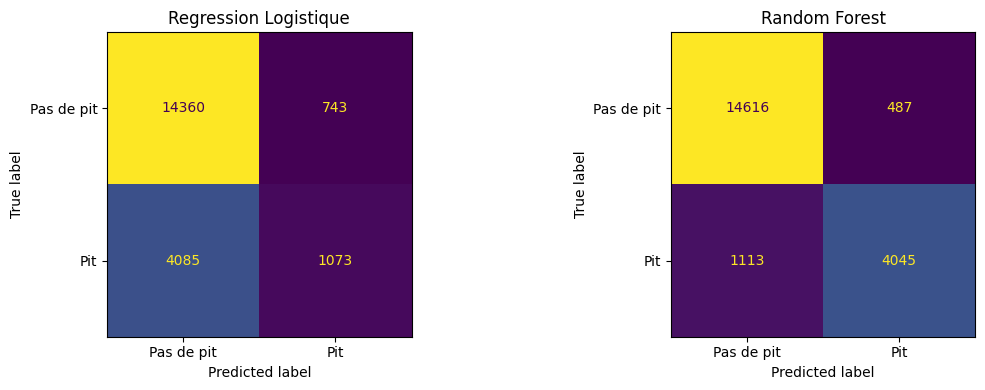

In [31]:
# Matrices de confusion — une par modele, cote a cote
# Chaque cellule de la matrice indique combien de cas tombent dans chaque categorie :
#   Vrai Negatif (TN) : predit 0, reel 0  -> bonne prediction
#   Vrai Positif (TP) : predit 1, reel 1  -> bonne prediction
#   Faux Positif (FP) : predit 1, reel 0  -> fausse alarme
#   Faux Negatif (FN) : predit 0, reel 1  -> pit rate (cas le plus couteux en F1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_rf], ['Regression Logistique', 'Random Forest']):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Pas de pit', 'Pit']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

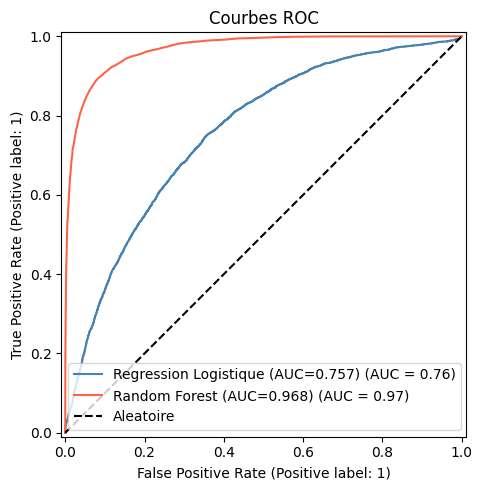

In [32]:

fig, ax = plt.subplots(figsize=(7, 5))
for model, name, color in zip([lr, rf], ['Regression Logistique', 'Random Forest'], ['steelblue', 'tomato']):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    RocCurveDisplay.from_predictions(y_test, y_proba, name=f'{name} (AUC={auc:.3f})', ax=ax, color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatoire')
ax.set_title('Courbes ROC')
ax.legend()
plt.tight_layout()
plt.show()

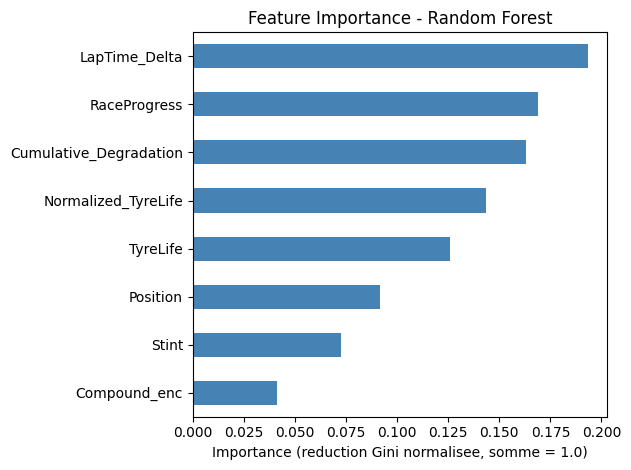

In [33]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance (reduction Gini normalisee, somme = 1.0)')
plt.tight_layout()
plt.show()